## Gamma Ray Bursts.

Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



### What I did, in short

Here is a summary of my analysis before diving into the details.

- **Load and clean the data**
    - I downloaded the GRBweb catalogue and parsed its 15 columns.
    - I kept only the bursts with positive $T_{90}$, fluence and $T_{100}$ (7850 events), and I worked in $\log_{10}$ since these quantities span many orders of magnitude.
    - I checked the sky map: the bursts are isotropic, as I expected for sources of cosmological origin.

- **1D analysis: looking for sub-populations**
    - I overplotted a histogram and a KDE for $\log T_{90}$, $\log T_{100}$ and $\log$ fluence. The two durations are clearly bimodal, the fluence is not.
    - I counted the components with BIC and AIC on $\log T_{90}$: both prefer $k=2$.
    - I located the short/long threshold as the crossing point of the two weighted Gaussians and I cross-checked it with a 1D K-Means.

- **2D analysis: clustering in $(\log T_{90}, \log \mathrm{fluence})$**
    - I removed the outliers with DBSCAN, then I clustered with Gaussian Mixture, K-Means and MeanShift.
    - For each method I picked the number of clusters with a criterion (AIC and silhouette), before and after removing the outliers.
    - GMM and K-Means both recover the two clusters; MeanShift fails, because the two populations overlap in density.

- **A check on errors and redshift, and my conclusions**
    - I checked that the measurement errors are small enough to be ignored.
    - I looked at how the redshift (which tells how far a source is from us) differs between the two classes.
    - I collected the thresholds found by all the methods and drew my conclusions.

## 1.  Load and clean the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV


from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)

In [2]:
# ── 1a. Download the catalogue ────────────────────────────────────────────────
import requests, io
URL = "https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt"
raw_text = requests.get(URL, timeout=60).text

# ── 1b. Parse with pandas (15 fixed, whitespace-separated columns) ────────────
COLS = ['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
        'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
        'redshift', 'T100', 'GBM_located', 'mjd']

df = pd.read_csv(io.StringIO(raw_text), sep=r'\s+', comment='#',
                 names=COLS, na_values=['-999', '-999.0', 'None'],
                 skip_blank_lines=True)

# Coerce the physical quantities to numeric (anything unparsable -> NaN)
for c in ['ra', 'decl', 'T90', 'T90_error', 'fluence', 'fluence_error', 'redshift', 'T100', 'mjd']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f"Total GRBs in the catalogue: {len(df)}")
print("\nHow many have a measured value for each key quantity:")
print(df[['T90', 'fluence', 'T100', 'redshift']].notna().sum().to_string())

Total GRBs in the catalogue: 9170

How many have a measured value for each key quantity:
T90         8000
fluence     8067
T100        7998
redshift     749


In [3]:
# Keep only physically meaningful, positive T90 / fluence / T100 (needed for log10).
mask = (df.T90 > 0) & (df.fluence > 0) & (df.T100 > 0)
sub = df[mask].copy()

t90       = sub.T90.values
fluence   = sub.fluence.values
t100      = sub.T100.values
redshift  = sub.redshift.values          # still contains NaN where unmeasured

# Log-transform (the natural coordinates)
log_t90     = np.log10(t90)
log_fluence = np.log10(fluence)
log_t100    = np.log10(t100)

# Feature matrix for the 2-D analysis
Dati = np.vstack([log_t90, log_fluence]).T

print(f"GRBs usable for the (T90, fluence) analysis: {len(sub)}")
print(f"With a measured redshift:        {np.isfinite(redshift).sum()}")

GRBs usable for the (T90, fluence) analysis: 7854
With a measured redshift:        680


#### Sanity check

A quick sanity/selection check: GRBs are extragalactic, so they should be **isotropic** on the sky.
Any strong anisotropy would betray an observational bias rather than physics.

- *ra*: Right ascension in J2000 coordinates. If the GRB was observed by multiple instruments, the localisation with the smallest angular uncertainty is used.

- *decl*: Declination in J2000 coordinates. If the GRB was observed by multiple instruments, the localisation with the smallest angular uncertainty is used.



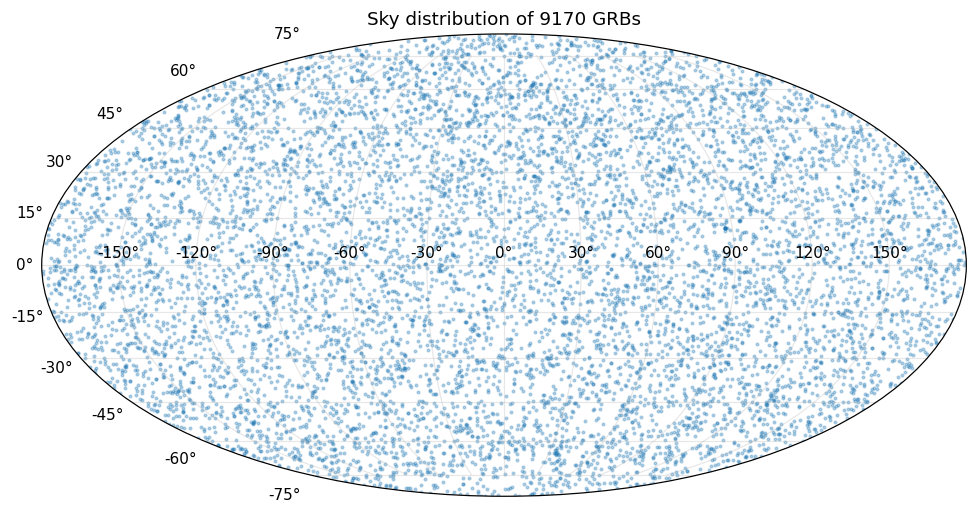

In [4]:
ra   = pd.to_numeric(df.ra, errors='coerce').values
decl = pd.to_numeric(df.decl, errors='coerce').values
ok   = np.isfinite(ra) & np.isfinite(decl)

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection='mollweide')
# Convert RA [0,360) -> [-pi, pi], Dec -> radians
ra_rad = np.radians(ra[ok]) - np.pi
dec_rad = np.radians(decl[ok])
ax.scatter(ra_rad, dec_rad, s=3, alpha=0.3, color='C0')
ax.grid(True, alpha=0.3)
ax.set_title(f"Sky distribution of {ok.sum()} GRBs")
plt.tight_layout(); plt.show()

The distribution is broadly **isotropic** consistent with a cosmological origin.

## 2. 1D analysis: looking for sub-populations

I've superimposed a histogram and a **Kernel Density Estimate (KDE)** for t90, t100 and fluence, looking for sub-populations. 


I've defined a function `kde_pdf(data, xgrid, bandwidth=None)` to estimate the KDE (Kernel Density Estimate) of the data, tested different bandwidth values using cross-validation via `GridSearchCV` and used the best-performing value to build the final KDE with `gaussian_kde`. Then, I've found the peaks of the density using `find_peaks` and printed the number of peaks found and their positions.

`find_peaks` is a Scipy function which finds all local maxima by simple comparison of neighboring values (I didn't use any particolar settings for it).



Number of peaks found for $\log_{10} T_{90}$: 2
Peaks at $\log_{10} T_{90}$:
  - 0.85 s
  - 37.20 s

Number of peaks found for $\log_{10}$ fluence: 1
Peaks at $\log_{10}$ fluence:
  - 1.84e-06 erg/cm²

Number of peaks found for $\log_{10} T_{100}$: 2
Peaks at $\log_{10} T_{100}$:
  - 1.02 s
  - 35.25 s


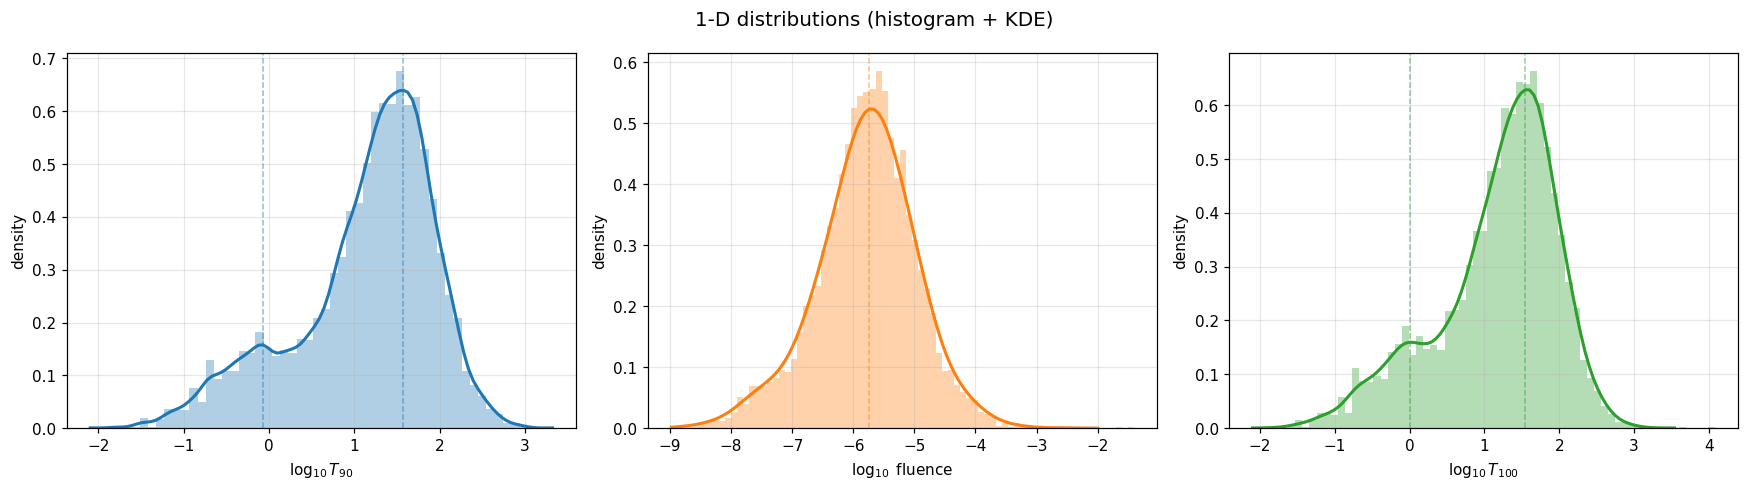

In [5]:
def kde_pdf(data, xgrid, bandwidth=None):    
    bwrange = np.linspace(0.01, 0.5, 20) # Test 20 bandwidths from 0.1 to 1.0
    K = 5 # Do 5-fold cross validation
    grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
    grid.fit(data[:, np.newaxis]) #Fit the histogram data 
    kde = gaussian_kde(data, bw_method=grid.best_params_['bandwidth'])
    return kde(xgrid)

variables = [
    (log_t90,     r"$\log_{10} T_{90}$",     "C0"),
    (log_fluence, r"$\log_{10}$ fluence",    "C1"),
    (log_t100,    r"$\log_{10} T_{100}$",    "C2"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (v, label, color) in zip(axes, variables):
    if label == r"$\log_{10}$ fluence":
        xg = np.linspace(v.min(), -2, 100)
    elif label == r"$\log_{10} T_{100}$":
        xg = np.linspace(v.min(), 3.54, 100)
    else:
        xg = np.linspace(v.min(), v.max(), 100)
    ax.hist(v, bins='auto', density=True, alpha=0.35, color=color)
    ax.plot(xg, kde_pdf(v, xg), color=color, lw=2)
    ax.set_xlabel(label); ax.set_ylabel("density")
    ax.grid(alpha=0.3)
    
    peaks, _ = find_peaks(kde_pdf(v, xg))
    print(f"\nNumber of peaks found for {label}: {len(peaks)}")
    print(f"Peaks at {label}:")
    for val in xg[peaks]:
        if label == r"$\log_{10}$ fluence":
            print(f"  - {10**val:.2e} erg/cm²")
        else:
            print(f"  - {10**val:.2f} s")
        ax.axvline(val, color=color, ls='--', lw=1, alpha=0.5)
    
    
        
fig.suptitle("1-D distributions (histogram + KDE)", fontsize=13)
plt.tight_layout(); plt.show()

**What I see:** 
- $\log_{10} T_{90}$ and $\log_{10} T_{100}$ are clearly bimodal, two humps with a valley near $\sim1$.
- $\log_{10}$ fluence, instead, looks essentially **uni-modal** even if the distribution doesn't seem perfectly simmetrical. Energy alone does not separate the classes.

So, there seem to be one type of bursts in terms of the fluence, while there are perhaps two distinct populations of bursts in terms of the duration. I will try to inverstigate the latter hypothesis using  the clustering methods we saw in our lecture considering $\log_{10}T_{90}$.

### How many sub-populations? Model selection with BIC/AIC

I've fitted Gaussian Mixtures with $k=1\ldots6$ components to $\log_{10}T_{90}$ and compare the
**Bayesian (BIC)** and **Akaike (AIC)** information criteria, both penalise extra parameters. The preferred $k$ is the one that **minimises** them.

BIC prefers k = 2
AIC prefers k = 2


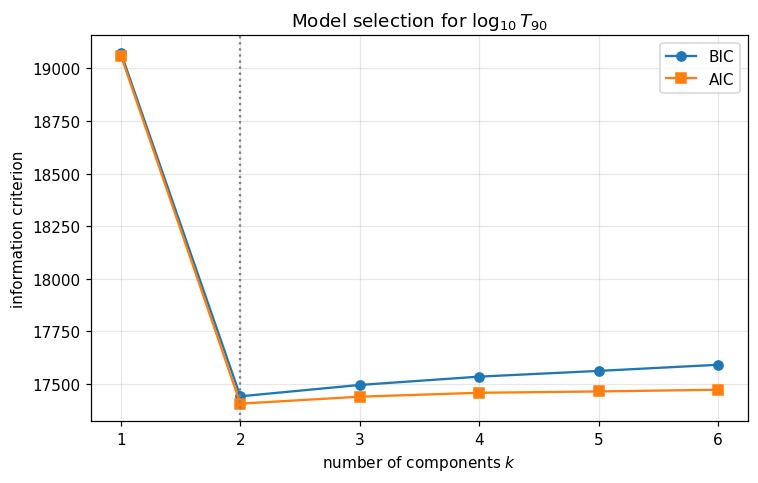

In [6]:
X1d = log_t90.reshape(-1, 1)
ks = np.arange(1, 7)
bic, aic = [], []
for k in ks:
    g = GaussianMixture(k, n_init=10, random_state=0).fit(X1d)
    bic.append(g.bic(X1d)); aic.append(g.aic(X1d))
bic, aic = np.array(bic), np.array(aic)

k_bic, k_aic = ks[bic.argmin()], ks[aic.argmin()]
print(f"BIC prefers k = {k_bic}")
print(f"AIC prefers k = {k_aic}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, bic, 'o-', label='BIC')
ax.plot(ks, aic, 's-', label='AIC')
ax.axvline(k_bic, color='grey', ls=':')
ax.set_xlabel("number of components $k$"); ax.set_ylabel("information criterion")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Model selection for $\\log_{10}T_{90}$")
plt.tight_layout(); plt.show()

Component means : T90 = 0.96 s (short),  30.36 s (long)
Weights         : 24% short,  76% long
Threshold (2-Gaussian crossing): log10 T90 = 0.578  ->  T90 = 3.79 s


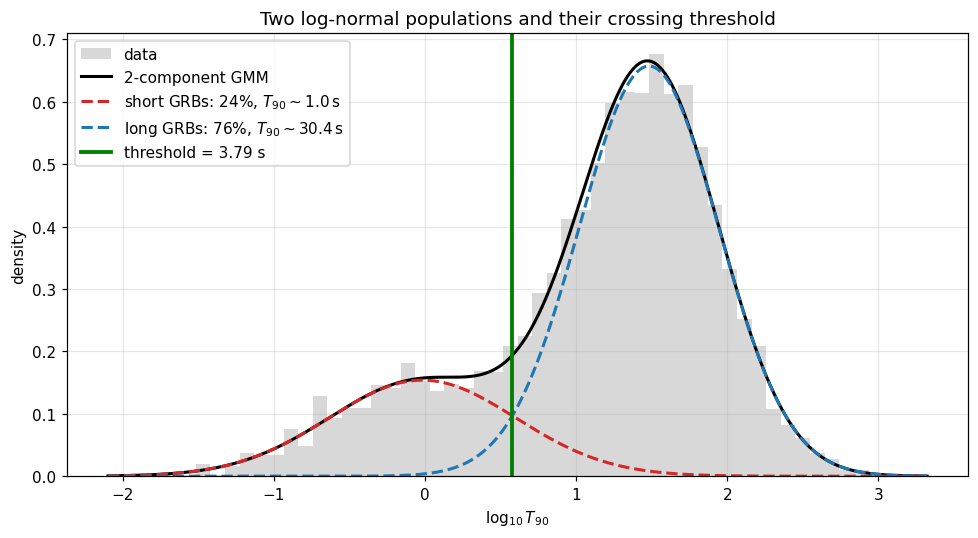

In [7]:
# Fit two Gaussians to log10(T90) and compute the class threshold DIRECTLY
from scipy.stats import norm
from scipy.optimize import fsolve

g2 = GaussianMixture(2, n_init=10, random_state=0).fit(X1d)
order = np.argsort(g2.means_.ravel())              # component 0 = short, 1 = long
mu = g2.means_.ravel()[order]
sd = np.sqrt(g2.covariances_.ravel())[order]
w  = g2.weights_[order]
(mu1, mu2), (sd1, sd2), (w1, w2) = mu, sd, w

# --- Threshold = crossing point of the two WEIGHTED Gaussians (Bayes boundary) ---
# the log10(T90) where w1 * N(x; mu1,sd1) == w2 * N(x; mu2,sd2)
def mixture_diff(x):
    return w1 * norm.pdf(x, mu1, sd1) - w2 * norm.pdf(x, mu2, sd2)

thr_logT90 = fsolve(mixture_diff, x0=(mu1 + mu2) / 2)[0]
thr_T90    = 10 ** thr_logT90
print(f"Component means : T90 = {10**mu1:.2f} s (short),  {10**mu2:.2f} s (long)")
print(f"Weights         : {w1*100:.0f}% short,  {w2*100:.0f}% long")
print(f"Threshold (2-Gaussian crossing): log10 T90 = {thr_logT90:.3f}  ->  T90 = {thr_T90:.2f} s")

# --- Plot: histogram, total mixture, each weighted Gaussian, and the threshold ---
xg = np.linspace(log_t90.min(), log_t90.max(), 1000).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(log_t90, bins='auto', density=True, alpha=0.3, color='grey', label='data')
ax.plot(xg, np.exp(g2.score_samples(xg)), 'k-', lw=2, label='2-component GMM')
for mui, sdi, wi, name, c in zip([mu1, mu2], [sd1, sd2], [w1, w2],
                                 ['short GRBs', 'long GRBs'], ['C3', 'C0']):
    ax.plot(xg, wi * norm.pdf(xg, mui, sdi), color=c, lw=2, ls='--',
            label=f'{name}: {wi*100:.0f}%, $T_{{90}}\\sim{10**mui:.1f}\\,$s')
ax.axvline(thr_logT90, color='green', lw=2.5,
           label=f'threshold = {thr_T90:.2f} s')
ax.set_xlabel(r"$\log_{10} T_{90}$"); ax.set_ylabel("density")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Two log-normal populations and their crossing threshold")
plt.tight_layout(); plt.show()

**How the threshold is computed.** The 2-component fit gives, for each population $i$, a weight
$w_i$, a mean $\mu_i$ and a width $\sigma_i$ in $\log_{10}T_{90}$. The natural class boundary is the point
where a burst is **equally likely to belong to either population**, i.e. where the two *weighted* Gaussians
have the same height:
$$w_1\,\mathcal N(x;\mu_1,\sigma_1)\;=\;w_2\,\mathcal N(x;\mu_2,\sigma_2).$$
I solve $w_1\mathcal N_1(x)-w_2\mathcal N_2(x)=0$ numerically with `fsolve`, starting
from the midpoint $(\mu_1+\mu_2)/2$, and convert back with $T_{90}=10^{\,x}$. 

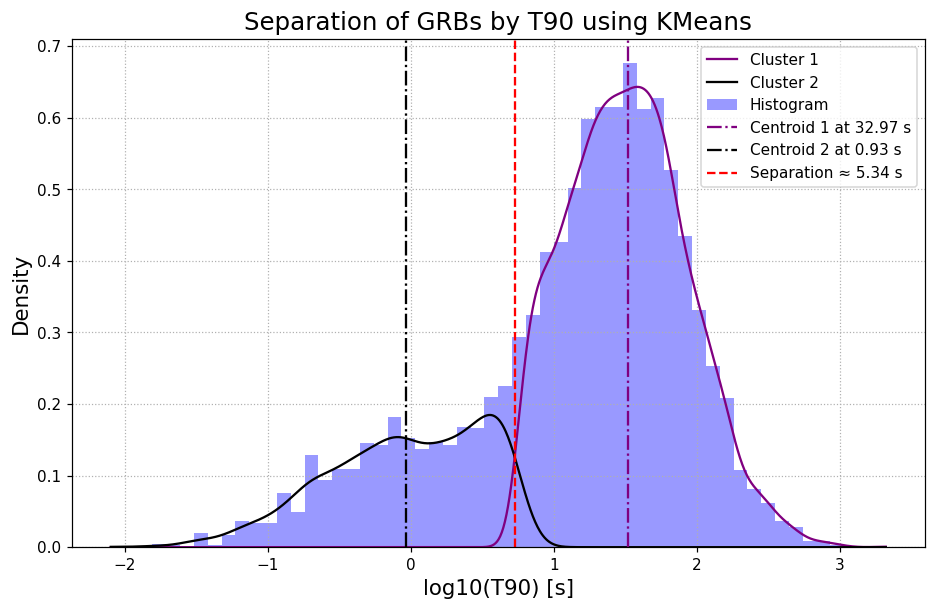

Separation point: 5.34 s


In [8]:
from scipy.stats import gaussian_kde

# 1. Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X1d)
Y_t = kmeans.predict(X1d)

centroids = kmeans.cluster_centers_.flatten()

# 2. Visualization setup
colors = ["purple", "black"]
plt.figure(figsize=(10,6))

# Log-transformed data
logT90_0 = X1d[Y_t == 0]
logT90_1 = X1d[Y_t == 1]

# Proportional weights
w0 = len(logT90_0) / len(X1d)
w1 = len(logT90_1) / len(X1d)

# KDEs
kde0 = gaussian_kde(logT90_0.ravel())
kde1 = gaussian_kde(logT90_1.ravel())

# 3. Plot ciascuna KDE pesata
x_min, x_max = float(X1d.min()), float(X1d.max())
x_vals = np.linspace(x_min, x_max, 1000)

plt.plot(x_vals, kde0(x_vals) * w0, color='purple', label='Cluster 1')
plt.plot(x_vals, kde1(x_vals) * w1, color='black', label='Cluster 2')

# 4. Plot istogramma
plt.hist(X1d, bins="fd", color='blue', density=True, alpha=0.4, edgecolor='none', label='Histogram')

# 5. Plot centroidi
for i in range(2):
    centroid = centroids[i]
    plt.axvline(centroid, linestyle='-.', color=colors[i], label=f'Centroid {i+1} at {10**centroid:.2f} s')

from scipy.optimize import brentq

# 6. Separation line
def kde_diff(x): 
    # kde(x) restituisce un array, quindi estraiamo il primo elemento con [0]
    val0 = kde0(x)[0] * w0
    val1 = kde1(x)[0] * w1
    return float(val0 - val1)

# Il punto di intersezione si trova tra i due centroidi
c_min, c_max = min(centroids), max(centroids)
separation_log = brentq(kde_diff, c_min, c_max)
separation_kmeans = 10**separation_log

plt.axvline(separation_log, color='red', linestyle='--', label=f'Separation ≈ {separation_kmeans:.2f} s')

# 7. Final touches
plt.xlabel('log10(T90) [s]', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Separation of GRBs by T90 using KMeans', fontsize=16)
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

print(f"Separation point: {separation_kmeans:.2f} s")

From this initial analysis I learned two main things: 
    
1) The variable that shows the multi-modality more evidently is the $T_{90}$ one, while the other two seem to have just one mode;

2) The two clustering methods I used returned quite different results.

## 3. 2D analysis: clustering in $(\log T_{90},\ \log \mathrm{fluence})$

In this section I am interested to cluster in the plane $(\log_{10}T_{90},\ \log_{10}\mathrm{fluence})$ with three different
algorithms: **Gaussian Mixture**, **K-Means** and **MeanShift**. For each one I:

1. choose the number of groups with a criterion,
2. **repeat the choice after removing outliers with `DBSCAN`**, to see how much the outliers drive the answer,
3. run the clustering with the number found, and, whenever that number is not 2, also force a **2-group**
   solution and read off the **short/long threshold** in $T_{90}$.

Outliers are detected with DBSCAN on the *standardized* features; K-Means keeps the raw-log space so that a
centroid's $x$-coordinate is directly $\log_{10}T_{90}$, while the density-based MeanShift uses the standardized space.

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups data based on their spatial density. In this algorithm, the eps parameter defines the maximum search radius around a point, meaning that any data point left isolated in a low-density area without enough neighbors within this distance is classified as an outlier.

In [9]:
# ── Feature spaces and the DBSCAN outlier mask ────────────────────────────────
from scipy.stats import norm
from scipy.optimize import fsolve

X_log = np.column_stack((log_t90, log_fluence))       # raw log space (KMeans / thresholds)
scaler = StandardScaler().fit(X_log)
X_std = scaler.transform(X_log)                        # standardized (DBSCAN / MeanShift)

def dbscan_mask(eps=0.3, min_samples=10):
    """Return a boolean mask: True = inlier, False = DBSCAN outlier (label -1)."""
    lab = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_std)
    return lab != -1

inl = dbscan_mask(eps=0.3)
print(f"DBSCAN (eps=0.3): {inl.sum()} inliers, {(~inl).sum()} outliers removed")

DBSCAN (eps=0.3): 7779 inliers, 75 outliers removed


### Gaussian Mixture
I scanned $k=1\ldots8$ Gaussians and pick the $k$ that **minimises the AIC**, once with all the data and once
after removing the DBSCAN outliers.

I used also the **silhouette score**. The Silhouette Score is a metric used to evaluate the quality of the clusters created by the model. In simple terms, it measures how similar each point is to its own cluster (cohesion) compared to how similar it is to other clusters (separation).

AIC-preferred k:         before = 3,  after outlier removal = 8
Silhouette-preferred k:  before = 2,  after outlier removal = 2


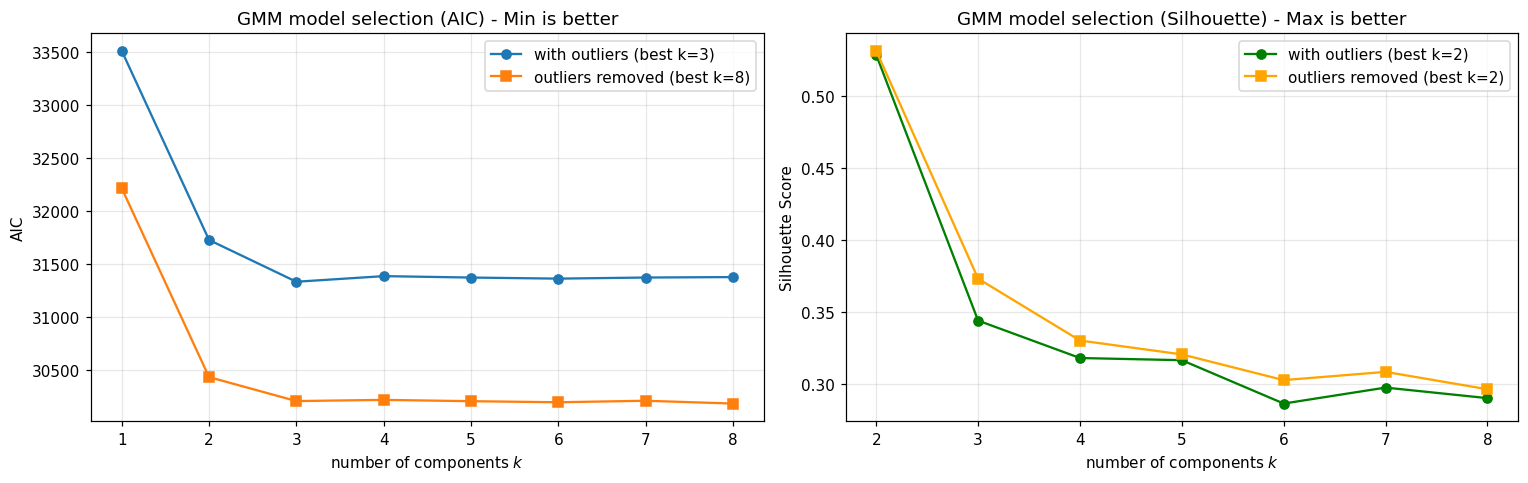

In [10]:
ks = np.arange(1, 9)

def aic_curve(X):
    return np.array([GaussianMixture(k, n_init=5, random_state=0).fit(X).aic(X) for k in ks])

# Nuova funzione per il Silhouette Score
def silhouette_curve(X):
    scores = []
    for k in ks:
        if k == 1:
            scores.append(np.nan) # Il Silhouette non è definito per 1 solo cluster
        else:
            gmm = GaussianMixture(k, n_init=5, random_state=0).fit(X)
            labels = gmm.predict(X)
            scores.append(silhouette_score(X, labels))
    return np.array(scores)

# Calcoli AIC (minimo è meglio)
aic_all = aic_curve(X_log)
aic_inl = aic_curve(X_log[inl])
kgmm_all = int(ks[aic_all.argmin()])
kgmm_inl = int(ks[aic_inl.argmin()])

# Calcoli Silhouette (massimo è meglio)
sil_all = silhouette_curve(X_log)
sil_inl = silhouette_curve(X_log[inl])
ksil_all = int(ks[np.nanargmax(sil_all)])
ksil_inl = int(ks[np.nanargmax(sil_inl)])

print(f"AIC-preferred k:         before = {kgmm_all},  after outlier removal = {kgmm_inl}")
print(f"Silhouette-preferred k:  before = {ksil_all},  after outlier removal = {ksil_inl}")

# Creazione dei grafici (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot AIC
ax1.plot(ks, aic_all, 'o-', label=f'with outliers (best k={kgmm_all})')
ax1.plot(ks, aic_inl, 's-', label=f'outliers removed (best k={kgmm_inl})')
ax1.set_xlabel('number of components $k$')
ax1.set_ylabel('AIC')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_title('GMM model selection (AIC) - Min is better')

# Plot Silhouette
ax2.plot(ks, sil_all, 'o-', color='green', label=f'with outliers (best k={ksil_all})')
ax2.plot(ks, sil_inl, 's-', color='orange', label=f'outliers removed (best k={ksil_inl})')
ax2.set_xlabel('number of components $k$')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_title('GMM model selection (Silhouette) - Max is better')

plt.tight_layout()
plt.show()

Using AIC, the curve keeps drifting down as the number of components increases, so it tends to
**over-segment**. Its minimum sits at $k>2$, and removing outliers pushes it even higher because the cleaned
data lets extra Gaussians chase fine structure. This is the influence of outlier in case of GGM, considering AIC.

Considering the quality of clusters (silhouette score), the preferred ones are the 2 clusters. The best metric to evaluate the performance of GGM used for clustering seems to be the Silhouette score. 

On the left, it's shown the clustering with the AIC-found $k=8$, and on the right, I forced the physical **2-component** split and extracted the threshold for T90.

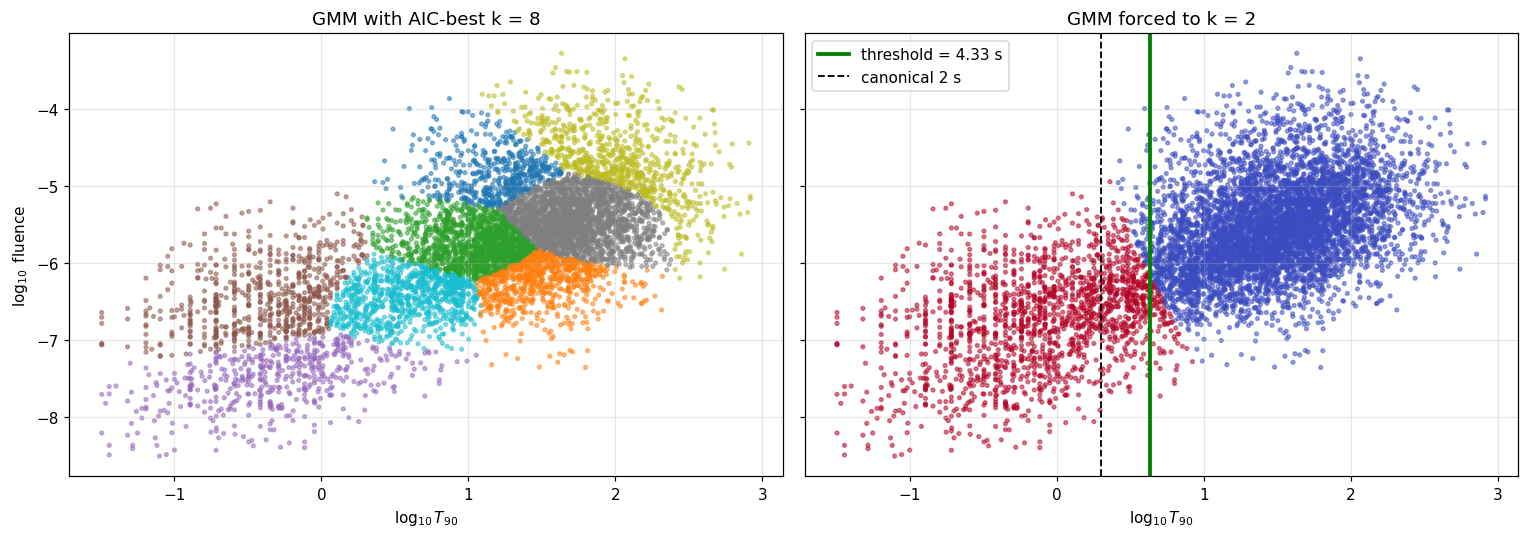

GMM (k=2) short/long threshold: log10 T90 = 0.636  ->  T90 = 4.33 s


In [11]:
def gmm_logT90_threshold(gm):
    # crossing of the two logT90-marginal WEIGHTED Gaussians: w1 N1(x) = w2 N2(x)
    o = np.argsort(gm.means_[:, 0])
    mu = gm.means_[o, 0]; sd = np.sqrt(gm.covariances_[o, 0, 0]); w = gm.weights_[o]
    f = lambda x: w[0]*norm.pdf(x, mu[0], sd[0]) - w[1]*norm.pdf(x, mu[1], sd[1])
    x = fsolve(f, (mu[0] + mu[1]) / 2)[0]
    return x, 10**x

Xin = X_log[inl]
gm_found = GaussianMixture(kgmm_inl, n_init=10, random_state=0).fit(Xin)
lab_found = gm_found.predict(Xin)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
axes[0].scatter(Xin[:, 0], Xin[:, 1], c=lab_found, cmap='tab10', s=6, alpha=0.5)
axes[0].set_title(f'GMM with AIC-best k = {kgmm_inl}')

gm2 = gm_found if kgmm_inl == 2 else GaussianMixture(2, n_init=10, random_state=0).fit(Xin)
lab2 = gm2.predict(Xin)
xthr_gmm, tthr_gmm = gmm_logT90_threshold(gm2)
axes[1].scatter(Xin[:, 0], Xin[:, 1], c=lab2, cmap='coolwarm', s=6, alpha=0.5)
axes[1].axvline(xthr_gmm, color='green', lw=2.5, label=f'threshold = {tthr_gmm:.2f} s')
axes[1].axvline(np.log10(2), color='k', ls='--', lw=1.2, label='canonical 2 s')
axes[1].set_title('GMM forced to k = 2'); axes[1].legend()
for ax in axes:
    ax.set_xlabel(r'$\log_{10} T_{90}$'); ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$\log_{10}$ fluence')
plt.tight_layout(); plt.show()
print(f"GMM (k=2) short/long threshold: log10 T90 = {xthr_gmm:.3f}  ->  T90 = {tthr_gmm:.2f} s")

### K-Means

Here, for the selector I chose the **silhouette score** (higher = better separated). I scanned $k=2\ldots8$
before and after removing the outliers, cluster with the best $k$. The threshold is the midpoint of **the two centroids** $\log_{10}T_{90}$ coordinates.

Silhouette-preferred k:  before = 2,  after outlier removal = 2


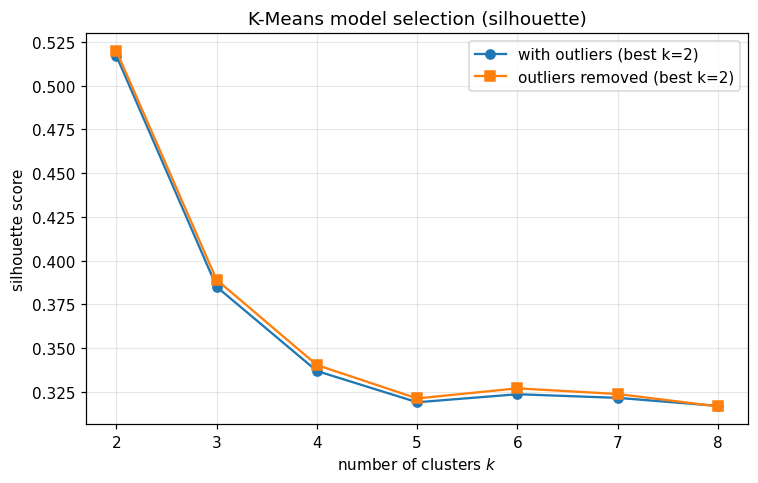

In [12]:
ks = np.arange(2, 9)
def sil_curve(X):
    return np.array([silhouette_score(X, KMeans(k, n_init=10, random_state=0).fit_predict(X)) for k in ks])

sil_all = sil_curve(X_log)
sil_inl = sil_curve(X_log[inl])
kkm_all = int(ks[sil_all.argmax()]); kkm_inl = int(ks[sil_inl.argmax()])
print(f"Silhouette-preferred k:  before = {kkm_all},  after outlier removal = {kkm_inl}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, sil_all, 'o-', label=f'with outliers (best k={kkm_all})')
ax.plot(ks, sil_inl, 's-', label=f'outliers removed (best k={kkm_inl})')
ax.set_xlabel('number of clusters $k$'); ax.set_ylabel('silhouette score')
ax.legend(); ax.grid(alpha=0.3); ax.set_title('K-Means model selection (silhouette)')
plt.tight_layout(); plt.show()

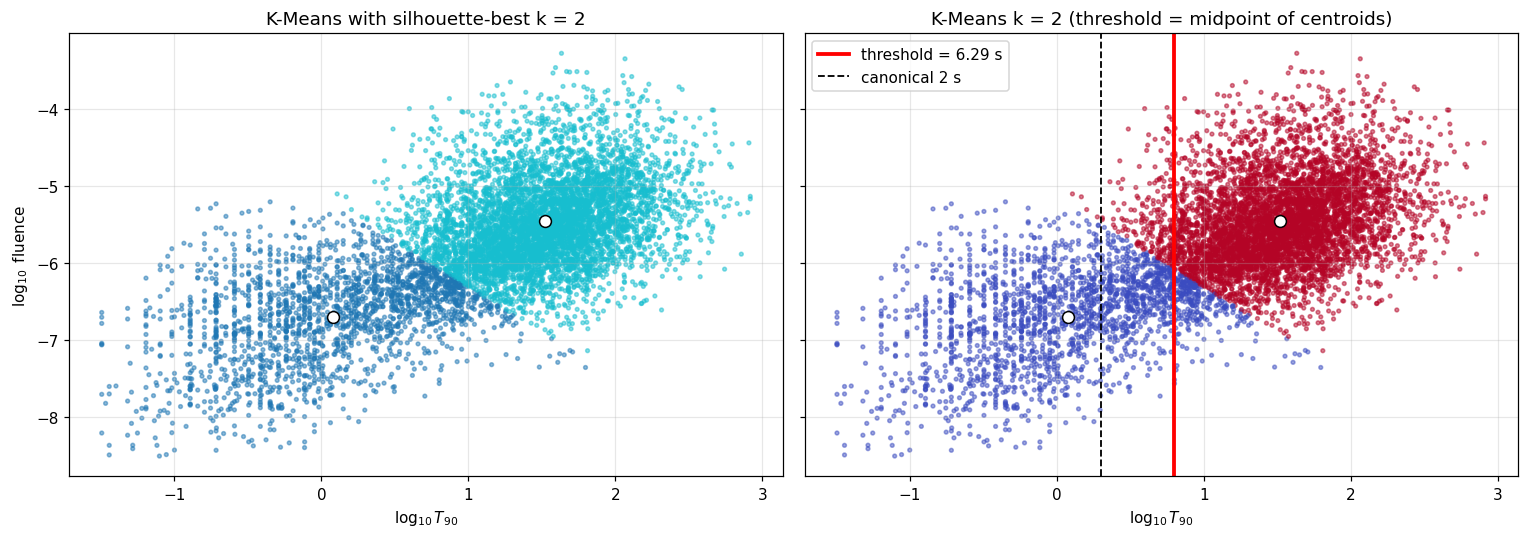

K-Means (k=2) centroids logT90 = [0.076 1.522]
K-Means (k=2) threshold: log10 T90 = 0.799  ->  T90 = 6.29 s


In [13]:
Xin = X_log[inl]
km_found = KMeans(kkm_inl, n_init=10, random_state=0).fit(Xin)
lab_found = km_found.predict(Xin)

# threshold from the 2-cluster solution (run k=2 explicitly if silhouette-best != 2)
km2 = km_found if kkm_inl == 2 else KMeans(2, n_init=10, random_state=0).fit(Xin)
cen = np.sort(km2.cluster_centers_[:, 0])
xthr_km = cen.mean(); tthr_km = 10**xthr_km
lab2 = km2.predict(Xin)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
axes[0].scatter(Xin[:, 0], Xin[:, 1], c=lab_found, cmap='tab10', s=6, alpha=0.5)
axes[0].scatter(km_found.cluster_centers_[:, 0], km_found.cluster_centers_[:, 1],
                c='w', edgecolors='k', s=60)
axes[0].set_title(f'K-Means with silhouette-best k = {kkm_inl}')
axes[1].scatter(Xin[:, 0], Xin[:, 1], c=lab2, cmap='coolwarm', s=6, alpha=0.5)
axes[1].scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1], c='w', edgecolors='k', s=60)
axes[1].axvline(xthr_km, color='red', lw=2.5, label=f'threshold = {tthr_km:.2f} s')
axes[1].axvline(np.log10(2), color='k', ls='--', lw=1.2, label='canonical 2 s')
axes[1].set_title('K-Means k = 2 (threshold = midpoint of centroids)'); axes[1].legend()
for ax in axes:
    ax.set_xlabel(r'$\log_{10} T_{90}$'); ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$\log_{10}$ fluence')
plt.tight_layout(); plt.show()
print(f"K-Means (k=2) centroids logT90 = {cen.round(3)}")
print(f"K-Means (k=2) threshold: log10 T90 = {xthr_km:.3f}  ->  T90 = {tthr_km:.2f} s")

### MeanShift

MeanShift has no "number of clusters" knob: it climbs the density towards its **modes**, and the number of
groups is fixed by the **bandwidth** returned by `estimate_bandwidth`. Because the two GRB populations
**overlap in density** (they differ in *location* along $T_{90}$, not in a density gap — recall DBSCAN saw a
single connected blob), MeanShift is very fragile. We look at three cases:
all data, outliers removed (75), and *more* outliers removed (204).

MeanShift [with outliers]: bandwidth=1.129 -> 3 clusters
MeanShift [outliers removed (eps=0.3)]: bandwidth=1.108 -> 1 clusters
MeanShift [more removed (eps=0.2)]: bandwidth=1.078 -> 1 clusters


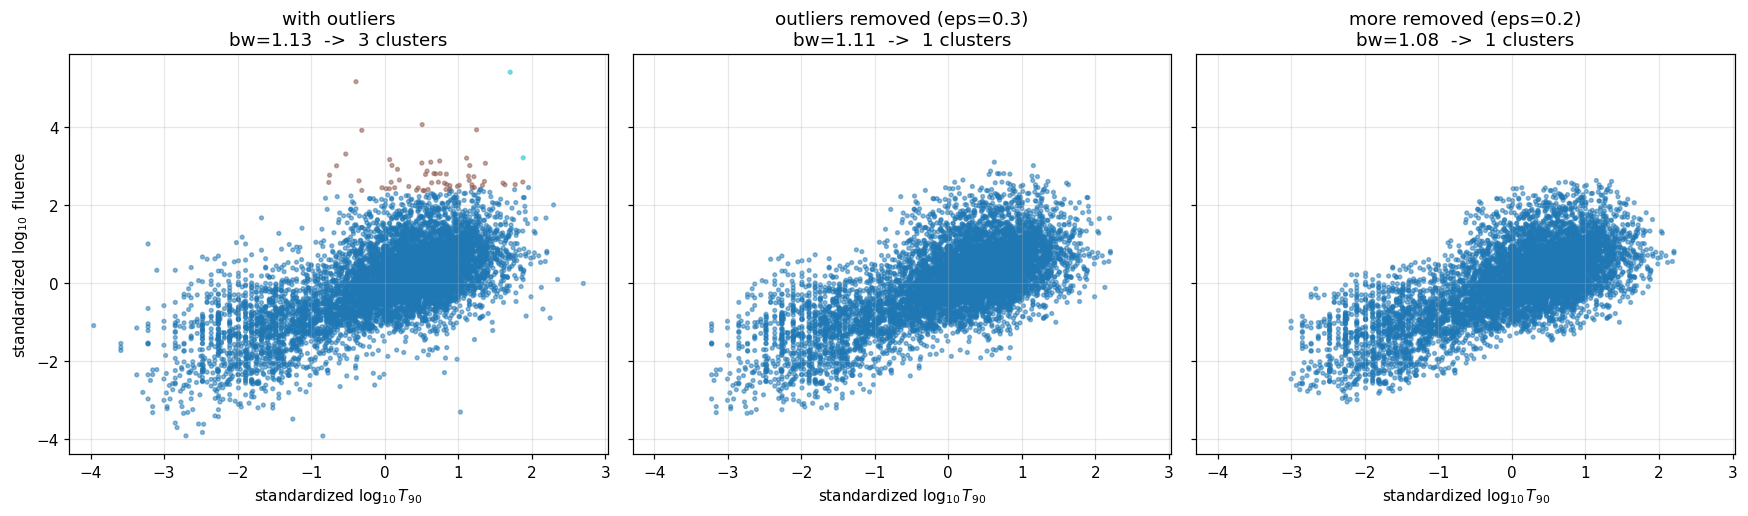

In [14]:
def meanshift_fit(X):
    bw = estimate_bandwidth(X, random_state=0)
    lab = MeanShift(bandwidth=bw, bin_seeding=True).fit_predict(X)
    return bw, lab, len(np.unique(lab))

scenarios = [
    ("with outliers",               X_std                    ),
    ("outliers removed (eps=0.3)",   X_std[dbscan_mask(0.3)]),
    ("more removed (eps=0.2)",       X_std[dbscan_mask(0.2)]),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
for ax, (name, Xd) in zip(axes, scenarios):
    bw, lab, n = meanshift_fit(Xd)
    ax.scatter(Xd[:, 0], Xd[:, 1], c=lab, cmap='tab10', s=6, alpha=0.5)
    ax.set_title(f'{name}\nbw={bw:.2f}  ->  {n} clusters')
    ax.set_xlabel(r'standardized $\log_{10} T_{90}$'); ax.grid(alpha=0.3)
    print(f"MeanShift [{name}]: bandwidth={bw:.3f} -> {n} clusters")
axes[0].set_ylabel(r'standardized $\log_{10}$ fluence')
plt.tight_layout(); plt.show()

**MeanShift is very sensitive to outliers and does *not* recover the two physical classes.** With the
outliers in, the automatic bandwidth splits the plane into several spurious clusters (driven by the sparse
tails, not by the short/long structure); once the outliers are removed the estimated bandwidth makes the two
overlapping populations merge into a **single** mode — and removing *more* outliers does not help. Unlike
K-Means and GMM, a pure density-mode seeker cannot separate populations that overlap in density, so here it is
the wrong tool.

**Section summary.** K-Means (silhouette $\to k=2$) and GMM (AIC over-segments, silhouette $\to k=2$) both
recover the short/long split and give thresholds of a few seconds (K-Means from the centroid midpoint, GMM
from the weighted-Gaussian crossing); MeanShift fails. The *existence* of two classes is robust; the exact
threshold depends on the method.

## 4. A check on errors and redshift, and my conclusions

### Do the measurement errors matter?

Up to now I clustered $T_{90}$ as if every value were exact, but each $T_{90}$ comes with a measurement error. Before trusting the result I should check that these errors are small. The simple test, which is also the one the professor uses in his solution, is to plot each error against its own $T_{90}$ value.

In [ ]:
he = np.isfinite(sub.T90_error.values) & (sub.T90_error.values > 0)
rel_err = (sub.T90_error.values / sub.T90.values)[he]
print(f"GRBs with a measured T90 error: {he.sum()} of {len(sub)}")
print(f"typical (median) error: about {np.median(rel_err)*100:.0f}% of the T90 value")

plt.figure(figsize=(7, 6))
plt.scatter(sub.T90.values[he], sub.T90_error.values[he], s=6, alpha=0.15, color='C0')
plt.plot([1e-2, 1e3], [1e-2, 1e3], 'k:', label='error = value')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'$T_{90}$ [s]'); plt.ylabel(r'error on $T_{90}$ [s]')
plt.title('Measurement error vs value'); plt.legend(); plt.grid(alpha=0.3, which='both')
plt.show()

Almost all the points sit well below the dotted line, where the error would equal the value: a typical error is only about a tenth of the $T_{90}$ it refers to. The two populations, on the other hand, are centred almost a factor 30 apart (about 1 s and 30 s). So the measurement noise is much smaller than the gap between the two classes: it blurs each point a little but cannot wash out the two humps. This is the same conclusion the professor reaches, and it means that **ignoring the errors, as I did, is fine**.

The only exception is at very small $T_{90}$ (bottom left), where the errors grow and get close to the values themselves. That is the least reliable part of the sample, and it is right where the short/long boundary sits, so it may explain part of why the different methods place the threshold at slightly different values.

### Redshifts

The catalogue also gives a redshift for some of the bursts. I read up on what this means for this exercise: the redshift $z$ measures how much the light of a source has been stretched by the expansion of the Universe while travelling to us, so a **larger $z$ means the source is farther away** (and its light left it longer ago). Using my short/long split I can ask whether the two classes are at different distances.

In [ ]:
from scipy.stats import ks_2samp, gaussian_kde

hasz  = np.isfinite(sub.redshift.values)
short = log_t90 < thr_logT90
z = sub.redshift.values

for name, m in [('short', short), ('long', ~short)]:
    n_tot, n_z = m.sum(), (hasz & m).sum()
    print(f"{name:5s}: {n_z:4d} of {n_tot:4d} have a redshift ({100*n_z/n_tot:.0f}%)")

zs, zl = z[hasz & short], z[hasz & ~short]
print(f"\nmedian redshift  short = {np.median(zs):.2f}   long = {np.median(zl):.2f}")
ks = ks_2samp(zs, zl)
print(f"KS test (short vs long redshift): p-value = {ks.pvalue:.1e}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(sub.T90.values[hasz & short], zs, s=16, alpha=0.6, color='C3', label='short')
ax[0].scatter(sub.T90.values[hasz & ~short], zl, s=16, alpha=0.6, color='C0', label='long')
ax[0].axvline(10**thr_logT90, color='k', ls='--', lw=1, label='threshold')
ax[0].set_xscale('log'); ax[0].set_ylim(0, 10)
ax[0].set_xlabel(r'$T_{90}$ [s]'); ax[0].set_ylabel('redshift $z$')
ax[0].set_title('Redshift vs duration'); ax[0].legend(); ax[0].grid(alpha=0.3, which='both')

xg = np.linspace(0, 8, 300)
ax[1].hist(zs, bins=20, density=True, alpha=0.35, color='C3')
ax[1].hist(zl, bins=20, density=True, alpha=0.35, color='C0')
ax[1].plot(xg, gaussian_kde(zs)(xg), color='C3', lw=2, label=f'short (median {np.median(zs):.2f})')
ax[1].plot(xg, gaussian_kde(zl)(xg), color='C0', lw=2, label=f'long (median {np.median(zl):.2f})')
ax[1].set_xlabel('redshift $z$'); ax[1].set_ylabel('density')
ax[1].set_title('Redshift distribution by class'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The two distributions are clearly different (the KS test gives a tiny p-value, so it is not a chance effect). Long GRBs are found much farther away (median $z\simeq1.7$) than short ones (median $z\simeq0.65$). I looked up the reason: long GRBs come from the collapse of massive stars, which are young and were abundant in the distant, early Universe, so we see them far away; short GRBs come from the merger of two dead stars (neutron stars), which takes a long time to happen, so they belong to an older and, on average, closer population.

I have to add a warning about selection, though. Only about 6% of the short bursts have a measured redshift, against about 10% of the long ones. Getting a redshift means following up the burst with other telescopes, which is harder for the short ones. So the few short bursts I have a redshift for are the closest and brightest, and part of the difference I see could be due to what we manage to observe rather than to a real difference. Separating the two would need a proper model of the selection, which goes beyond what I did here.

### Conclusions

Putting everything together, referring only to what I actually did:

- **Load and clean.** From the $\sim9000$ GRBs in the catalogue I kept the 7850 with a good $T_{90}$, fluence and $T_{100}$, worked in $\log_{10}$, and checked that they are spread isotropically on the sky, as expected for cosmological sources.

- **1D analysis.** The duration ($T_{90}$ and $T_{100}$) is clearly bimodal, while the fluence is not: the energy alone does not separate the bursts. BIC and AIC both prefer two Gaussian components, centred at about 1 s and 30 s. So $T_{90}$ is the variable that shows the two populations best.

- **2D analysis.** In the $(\log T_{90}, \log \mathrm{fluence})$ plane, after removing 75 outliers with DBSCAN, both Gaussian Mixture and K-Means recover two clusters (the silhouette score confirms $k=2$, while the AIC over-counts). MeanShift instead fails: the two populations overlap in density, so a method that looks for density peaks merges them into one.

- **Thresholds.** Every method that splits the sample places the short/long boundary at a few seconds:

    | method | threshold |
    |--------|-----------|
    | 1D, two-Gaussian crossing | $\sim 3.8$ s |
    | 1D, K-Means | $\sim 5.3$ s |
    | 2D, Gaussian Mixture ($k=2$) | $\sim 4.3$ s |
    | 2D, K-Means ($k=2$) | $\sim 6.3$ s |

    The values differ a bit from method to method, but all sit close to the value of about 2 s that is usually quoted in the literature. It is a soft boundary, not a sharp line.

- **Errors and redshift.** The measurement errors are much smaller than the separation between the two classes, so ignoring them is justified. The redshifts show that long GRBs are farther than short ones, consistent with their different physical origin, although selection effects make this last point only tentative.

**Final answer.** The data contain two sub-populations, the short and the long GRBs, separated at a duration of a few seconds. This matches the known physics: short bursts from the merger of compact objects, long bursts from the collapse of massive stars.